# Simpy

Generando animación... Por favor espera unos segundos.
¡Éxito! La animación se ha guardado como 'simulacion_logistica.gif'.


'c:\\Users\\morenlu\\AppData\\Local\\Programs\\Microsoft VS Code'

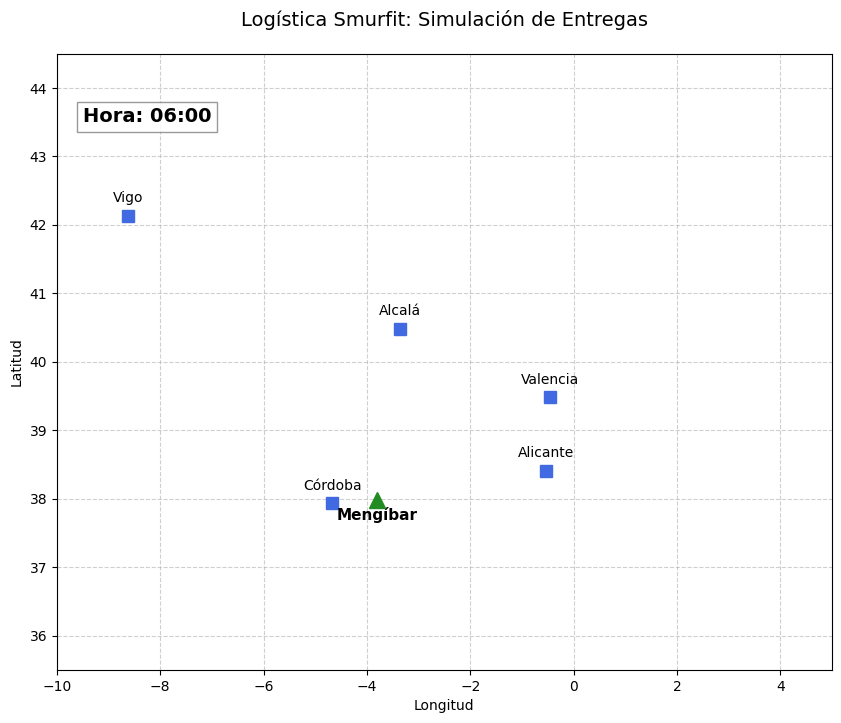

In [ ]:
import math
import simpy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# --- 1. DATOS EXACTOS DE UBICACIONES ---
PLANTA_PAPEL = {"name": "Mengíbar", "lat": 37.98148, "lng": -3.80058}
PLANTAS_CARTON = [
    {"name": "Alcalá", "lat": 40.48205, "lng": -3.35996},
    {"name": "Alicante", "lat": 38.40289, "lng": -0.54019},
    {"name": "Córdoba", "lat": 37.93214, "lng": -4.67292},
    {"name": "Valencia", "lat": 39.47960, "lng": -0.46162},
    {"name": "Vigo", "lat": 42.13338, "lng": -8.62150},
]

VELOCIDAD_KMH = 80
TIEMPO_CARGA_HORAS = 0.5

def haversine(lat1, lng1, lat2, lng2):
    R = 6371
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    a = math.sin(math.radians(lat2 - lat1)/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(math.radians(lng2 - lng1)/2)**2
    return round(R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a)), 1)

# --- 2. MOTOR DE SIMULACIÓN CON SIMPY ---
log_viajes = []

def proceso_camion(env, id_camion, destino, muelle, conductores):
    """
    Simula el ciclo de vida del camión con DOS cuellos de botella:
    Primero necesita el muelle. Luego, necesita un conductor.
    """
    # 1era Fase: Carga en el muelle
    with muelle.request() as peticion_muelle:
        yield peticion_muelle 
        # Tarda 30 minutos en cargar
        yield env.timeout(TIEMPO_CARGA_HORAS)
    
    # Al salir del bloque 'with muelle', el muelle queda libre para otro camión.
    # Pero nuestro camión cargado ahora debe esperar a un conductor.

    # 2da Fase: Viaje por carretera
    with conductores.request() as peticion_conductor:
        yield peticion_conductor
        
        # ¡Por fin tiene conductor! Registramos la hora real de salida a la carretera
        hora_salida = env.now
        
        distancia_km = haversine(PLANTA_PAPEL["lat"], PLANTA_PAPEL["lng"], destino["lat"], destino["lng"])
        tiempo_viaje = (distancia_km * 1.3) / VELOCIDAD_KMH
        
        # El conductor está ocupado todo el tiempo que dura el viaje
        yield env.timeout(tiempo_viaje)
        
        hora_llegada = env.now
    
    # Al terminar el viaje y salir del bloque 'with conductores', el conductor queda libre.
    
    # Guardamos los datos para la animación
    log_viajes.append({
        "id": id_camion, "destino": destino["name"],
        "t_salida_h": hora_salida, "t_llegada_h": hora_llegada,
        "lon_origen": PLANTA_PAPEL["lng"], "lat_origen": PLANTA_PAPEL["lat"],
        "lon_destino": destino["lng"], "lat_destino": destino["lat"]
    })

# Configuración del entorno y RECURSOS
env = simpy.Environment(initial_time=6.0)

# Aquí definimos nuestras reglas de negocio (Limitaciones)
muelle_mengibar = simpy.Resource(env, capacity=1)   # Solo 1 camión carga a la vez
conductores_flota = simpy.Resource(env, capacity=2) # Solo 2 camiones pueden viajar al mismo tiempo

for i, destino in enumerate(PLANTAS_CARTON):
    env.process(proceso_camion(env, f"TRK-{i+1}", destino, muelle_mengibar, conductores_flota))

env.run()

# --- 3. CREACIÓN Y GUARDADO DEL GIF ---
print("Generando animación GIF... Por favor espera (versión optimizada).")

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(-10, 5)
ax.set_ylim(35.5, 44.5)
ax.set_title("Logística Smurfit: 1 Muelle, 2 Conductores", fontsize=14, pad=20)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.grid(True, linestyle='--', alpha=0.6)

for p in PLANTAS_CARTON:
    ax.plot(p["lng"], p["lat"], 's', color='royalblue', markersize=8)
    ax.text(p["lng"], p["lat"] + 0.2, p["name"], fontsize=10, ha='center')

ax.plot(PLANTA_PAPEL["lng"], PLANTA_PAPEL["lat"], '^', color='forestgreen', markersize=12)
ax.text(PLANTA_PAPEL["lng"], PLANTA_PAPEL["lat"] - 0.3, PLANTA_PAPEL["name"], fontsize=11, ha='center', weight='bold')

camiones_scatter = ax.scatter([], [], c='crimson', s=80, zorder=5, edgecolors='black')
texto_reloj = ax.text(-9.5, 43.5, '', fontsize=14, weight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# Optimización: saltos de 0.2 horas (12 minutos) para generar la mitad de fotogramas y tardar menos
fotogramas = np.arange(6.0, 20.0, 0.2)

def actualizar(tiempo_actual):
    x_actual = []
    y_actual = []

    for viaje in log_viajes:
        if viaje["t_salida_h"] <= tiempo_actual <= viaje["t_llegada_h"]:
            tiempo_total = viaje["t_llegada_h"] - viaje["t_salida_h"]
            progreso = (tiempo_actual - viaje["t_salida_h"]) / tiempo_total
            
            lon = viaje["lon_origen"] + (viaje["lon_destino"] - viaje["lon_origen"]) * progreso
            lat = viaje["lat_origen"] + (viaje["lat_destino"] - viaje["lat_origen"]) * progreso
            
            x_actual.append(lon)
            y_actual.append(lat)

    if x_actual:
        camiones_scatter.set_offsets(np.c_[x_actual, y_actual])
    else:
        camiones_scatter.set_offsets(np.empty((0, 2)))

    horas = int(tiempo_actual)
    minutos = int((tiempo_actual % 1) * 60)
    texto_reloj.set_text(f"Hora: {horas:02d}:{minutos:02d}")

    return camiones_scatter, texto_reloj

animacion = animation.FuncAnimation(fig, actualizar, frames=fotogramas, blit=False)

# Guardar como GIF
nombre_archivo = 'simulacion_conductores.gif'
animacion.save(nombre_archivo, writer='pillow', fps=8, dpi=80)

print(f"¡Éxito! La animación se ha guardado como '{nombre_archivo}'.")